In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.model_selection import StratifiedKFold, GridSearchCV

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IBM-Employee-Attrition.csv to IBM-Employee-Attrition.csv


**Features with their value representation**


Education

1 'Below College'
2 'College'
3 'Bachelor'
4 'Master'
5 'Doctor'

EnvironmentSatisfaction

1 'Low'
2 'Medium'
3 'High'
4 'Very High'

JobInvolvement

1 'Low'
2 'Medium'
3 'High'
4 'Very High'

JobSatisfaction

1 'Low'
2 'Medium'
3 'High'
4 'Very High'

PerformanceRating

1 'Low'
2 'Good'
3 'Excellent'
4 'Outstanding'

RelationshipSatisfaction

1 'Low'
2 'Medium'
3 'High'
4 'Very High'

WorkLifeBalance

1 'Bad'
2 'Good'
3 'Better'
4 'Best

In [ ]:
data = pd.read_csv('IBM-Employee-Attrition.csv')
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [ ]:
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


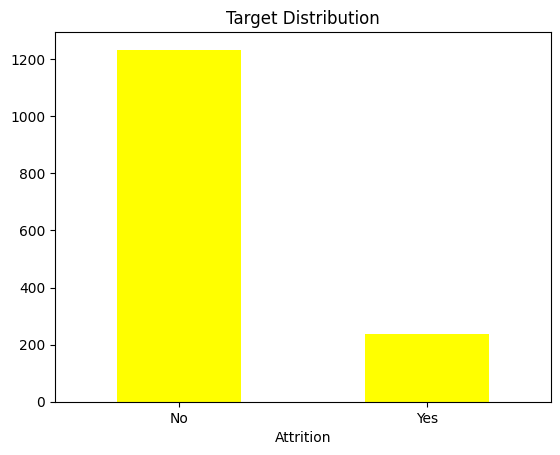

In [ ]:
data['Attrition'].value_counts().plot(kind='bar',color='yellow')
plt.title('Target Distribution')
plt.xticks(rotation=0)
plt.show()

In [ ]:
print(f'Percentage of employee attrition: {round(100*((data["Attrition"].value_counts())/len(data)))}')

Percentage of employee attrition: Attrition
No     84.0
Yes    16.0
Name: count, dtype: float64


In [ ]:
data.describe(include="O").T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [ ]:
data['Over18'].value_counts()

,count
Over18,
Y,1470


In [ ]:
data['EmployeeCount'].value_counts()

,count
EmployeeCount,
1,1470


In [ ]:
data['StandardHours'].value_counts()

,count
StandardHours,
80,1470


In [ ]:
data = data.drop(columns=['Over18','EmployeeCount','StandardHours'], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = data.drop(columns=['Attrition'], axis=1)
y = data['Attrition']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=62)

In [ ]:
cat_col = x.select_dtypes(include='object').columns.tolist()
num_col = x.select_dtypes(exclude="object").columns.tolist()

In [ ]:
print(f'Total Categorical columns: {len(cat_col)}\nTotal Numerical columns: {len(num_col)}')

Total Categorical columns: 7
Total Numerical columns: 24


In [ ]:
tf1 = ColumnTransformer([
    ('categorical', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_col),
    ('numerical', StandardScaler(), num_col)
], remainder='passthrough')



In [ ]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [ ]:
lo = LogisticRegression()
dt = DecisionTreeClassifier(random_state=42)
svm = SVC()

In [ ]:
model = {
    'Logistic regression': lo,
    'Decision Tree': dt,
    'SVM': svm
}

In [ ]:
pipe = ImbPipeline(steps=[
    ('preprocessor',tf1),
    ('smote',SMOTE(random_state=42)),
    ('feature_selection',SelectKBest(k=20, score_func=mutual_info_classif)),
    ('classifier',lo)

])

In [ ]:
param_lo = {
    'classifier': [lo]
}

param_dt = {
    'classifier': [dt],
    'classifier__criterion': ['gini','entropy'],
    'classifier__max_depth': [3,5,10, None]
}

param_svm = {
    'classifier': [svm],
    'classifier__kernel': ['linear','rbf'],
    'classifier__C': [0.01,0.1,1]
}


params = [param_lo, param_dt, param_svm]

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
for name, param in zip(model.keys(), params):
  print(f'Model: {name}')
  grid = GridSearchCV(estimator=pipe, param_grid=param, cv=cv, scoring='roc_auc')
  grid.fit(x_train, y_train_encoded)
  print(f'Best Score: {grid.best_score_}\nBest Params: {grid.best_params_}')
  y_pred = grid.predict(x_test)
  print(f'Accuracy: {accuracy_score(y_test_encoded,y_pred)}')
  print(f'classification_report: {classification_report(y_test_encoded,y_pred)}')
  print('**************************')


Model: Logistic regression
Best Score: 0.811505376344086
Best Params: {'classifier': LogisticRegression()}
Accuracy: 0.7554347826086957
classification_report:               precision    recall  f1-score   support

           0       0.91      0.78      0.84       303
           1       0.38      0.63      0.48        65

    accuracy                           0.76       368
   macro avg       0.65      0.71      0.66       368
weighted avg       0.82      0.76      0.78       368

**************************
Model: Decision Tree
Best Score: 0.7295125146832927
Best Params: {'classifier': DecisionTreeClassifier(random_state=42), 'classifier__criterion': 'entropy', 'classifier__max_depth': 5}
Accuracy: 0.7472826086956522
classification_report:               precision    recall  f1-score   support

           0       0.88      0.81      0.84       303
           1       0.34      0.46      0.39        65

    accuracy                           0.75       368
   macro avg       0.61      0.6

In [ ]:
grid.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime']),
                                                 ('numerical', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EmployeeNum...
                                                   'RelationshipSatisfaction',
                                                   'StockOptionLevel',
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager'])])),
                ('smote', SMOTE(random_state=42)),
                ('feature_selection',
                 SelectKBest(k=20,
                             score_func=<function mutual_info_classif at 0x7ff0f2daac00>)),
                ('classifier', SVC(C=1, kernel='linear'))])

In [ ]:
pipe.named_steps

{'preprocessor': ColumnTransformer(remainder='passthrough',
                   transformers=[('categorical',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  ['BusinessTravel', 'Department',
                                   'EducationField', 'Gender', 'JobRole',
                                   'MaritalStatus', 'OverTime']),
                                 ('numerical', StandardScaler(),
                                  ['Age', 'DailyRate', 'DistanceFromHome',
                                   'Education', 'EmployeeNumber',
                                   'EnvironmentSatisfaction', 'HourlyRate',
                                   'JobInvolvement', 'JobLevel',
                                   'JobSatisfaction', 'MonthlyIncome',
                                   'MonthlyRate', 'NumCompaniesWorked',
                                   'PercentSalaryHi

Final features on which the model was trained.

In [ ]:
best_pipeline = grid.best_estimator_

In [ ]:
selected_features_mask = best_pipeline.named_steps['feature_selection'].get_support()

In [ ]:
transformed_feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [ ]:
print(f"Features selected: {transformed_feature_names[selected_features_mask]}")

Features selected: ['categorical__OverTime_No' 'categorical__OverTime_Yes' 'numerical__Age'
 'numerical__DistanceFromHome' 'numerical__Education'
 'numerical__EnvironmentSatisfaction' 'numerical__HourlyRate'
 'numerical__JobInvolvement' 'numerical__JobLevel'
 'numerical__JobSatisfaction' 'numerical__NumCompaniesWorked'
 'numerical__PercentSalaryHike' 'numerical__RelationshipSatisfaction'
 'numerical__TotalWorkingYears' 'numerical__TrainingTimesLastYear'
 'numerical__WorkLifeBalance' 'numerical__YearsAtCompany'
 'numerical__YearsInCurrentRole' 'numerical__YearsSinceLastPromotion'
 'numerical__YearsWithCurrManager']
